In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout ,Flatten
from tensorflow.keras import backend as k

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


x_train (60000, 28, 28) sample patch 
: [[  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


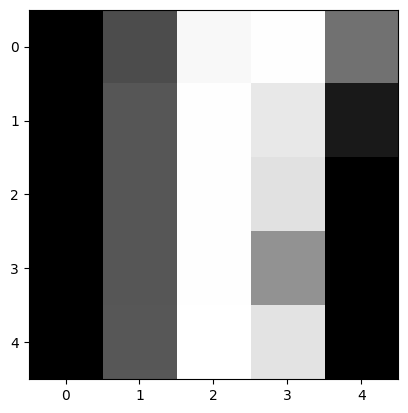

In [3]:
import matplotlib.pyplot as plt
print("x_train %s sample patch \n:" % (str(x_train.shape)), x_train[1, 15:20, 5:10])
plt.imshow(x_train[1,15:20,5:10], cmap='gray')
#plt.imshow(x_train[1,15:20,5:10],)
#print(str(x_train.shape))

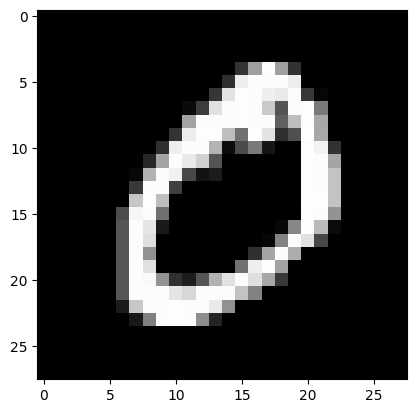

In [4]:
plt.imshow(x_train[1], cmap='gray')
plt.show()

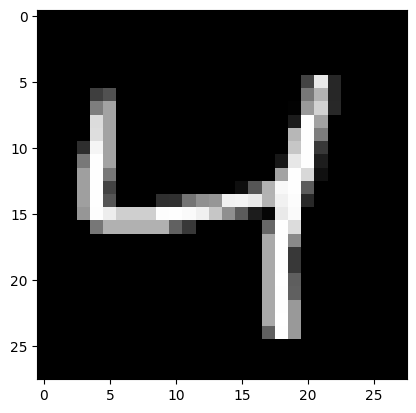

In [5]:
plt.imshow(x_train[2], cmap='gray')
plt.show()

In [6]:
import tensorflow as tf
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
    tf.keras.layers.Dense(100, activation = 'relu'),
    tf.keras.layers.Dense(60, activation = 'relu'),
    tf.keras.layers.Dense(30, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])
model.summary()

c:\Users\modern\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [8]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9120 - loss: 0.2944 - val_accuracy: 0.9592 - val_loss: 0.1329
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9658 - loss: 0.1124 - val_accuracy: 0.9705 - val_loss: 0.0986
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9771 - loss: 0.0762 - val_accuracy: 0.9706 - val_loss: 0.0958
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9818 - loss: 0.0577 - val_accuracy: 0.9719 - val_loss: 0.1028
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9758 - val_loss: 0.0886
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9879 - loss: 0.0382 - val_accuracy: 0.9721 - val_loss: 0.1015
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9899 - loss: 0.0321 - val_accuracy: 0.9763 - val_loss: 0.0953
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9907 - loss: 0.0278 - val_accurac

In [9]:
test_loss , test_acc = model.evaluate(x_test,y_test)
print("Test accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9732 - loss: 0.1024
Test accuracy:  0.9732000231742859


In [10]:
import numpy as np
def get_random_indecies(total_images,num_images):
    indecies= np.random.choice(total_images, num_images, replace=False)
    return indecies

In [11]:
predictions = model.predict(x_test)
x_test_images = x_test.reshape(-1,28,28)
predictions_classes = np.argmax(predictions,axis=1)
true_classes = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [12]:
num_images_to_show = 5
random_indecies = get_random_indecies(len(x_test_images), num_images_to_show)
def plot_images (images,labels,predictions):
    plt.figure(figsize=(10,9))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Actual: {labels[i]}\n Predicted: {predictions[i]}")
        plt.axis('off')
    plt.show()

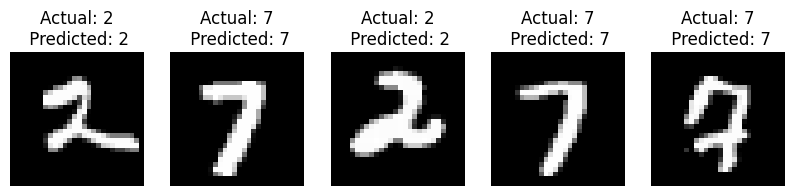

In [13]:
plot_images(x_test_images[random_indecies], true_classes[random_indecies], predictions_classes[random_indecies])

In [16]:
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.5 MB 1.0 MB/s eta 0:00:05
   ----- ---------------------------------- 0.8/5.5 MB 884.1 kB/s eta 0:00:06
   ------- -------------------------------- 1.0/5.5 MB 1.0 MB/s eta 0:00:05
   --------- ------------------------------ 1.3/5.5 MB 1.1 MB/s eta 0:00:04
   --------- ------------------------------ 1.3/5.5 MB 1.1 MB/s eta 0:00:04
   --------- ------------------------------ 1.3/5.5 MB 1.1 MB/s eta 0:00:04
   ----------- ---------------------------- 1.6/5.5 MB 791.5 kB/s eta 0:00:05
   ----------- ---------------------------- 1.6/5.5 MB 791.5 kB/s eta 0:00:05
   --------------- ------------------------ 2.1/5.5 MB 851.1 kB/s eta 0:00:05
   ----------------- ---------------------- 2.4/5.5 MB 883.0 kB/s eta 0:00:04
   ------------------ -


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

list_activations = ['sigmoid', 'relu', 'tanh']
list_optimizers = ['adam', 'rmsprop']

i = 1
for activation in list_activations:
    for optimizer in list_optimizers:
        NAME = f'mnist-{activation}-{optimizer}-v{i}'
        print(f"Training session: {NAME}")
        
        tensorboard_callback = TensorBoard(log_dir=f'logs/{NAME}')

        model = tf.keras.Sequential([
            tf.keras.layers.Dense(200, activation=activation, input_shape=(784,)),
            tf.keras.layers.Dense(100, activation=activation),
            tf.keras.layers.Dense(60, activation=activation),
            tf.keras.layers.Dense(10, activation='softmax')
        ])

        model.compile(optimizer=optimizer,
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        model.fit(x_train, y_train, 
                  epochs=5, 
                  batch_size=64, 
                  validation_split=0.2, 
                  callbacks=[tensorboard_callback])
        
        i += 1

Training session: mnist-sigmoid-adam-v1
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.8137 - loss: 0.7275 - val_accuracy: 0.9243 - val_loss: 0.2817
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9332 - loss: 0.2384 - val_accuracy: 0.9497 - val_loss: 0.1889
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9534 - loss: 0.1625 - val_accuracy: 0.9582 - val_loss: 0.1458
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9651 - loss: 0.1224 - val_accuracy: 0.9638 - val_loss: 0.1232
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9726 - loss: 0.0965 - val_accuracy: 0.9691 - val_loss: 0.1062
Training session: mnist-sigmoid-rmsprop-v2
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.7678 - loss: 0.8573 - val_accuracy: 0.8964 - val_loss: 0.3473
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9201 - loss: 0.2783 - val_accuracy: 0.9343 - val_loss: 0.2272
Epoch 3/5
750/750 

In [18]:
!tensorboard --logdir = logs --port = 6006

c:\Users\modern\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorboard\default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1776152326.207486   15196 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776152338.952410   15196 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH